In [2]:
# ============================================
# Cell 0: Mount Google Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# ============================================
# Cell 1: Python & Environment Check
# ============================================
import sys
print("Python version:", sys.version.split()[0])


Python version: 3.12.12


In [3]:
# ============================================
# Cell 2: Install Required Packages
# ============================================
!pip install --quiet git+https://github.com/openai/CLIP.git
!pip install --quiet torch torchvision pillow matplotlib pandas tqdm kaggle seaborn scikit-learn


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00


In [1]:
# ============================================
# Cell 3: Check GPU Availability
# ============================================
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("GPU Memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))


Torch version: 2.9.0+cu126
CUDA available: True
GPU Name: Tesla T4
GPU Memory (GB): 14.74


In [8]:
# ============================================
# Cell 4: Setup Kaggle API (Optional)
# ============================================
import os
if os.path.exists('/content/kaggle.json'):
    !mkdir -p ~/.kaggle
    !cp /content/kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("kaggle.json installed")
else:
    print("No kaggle.json found. Please upload it to /content if needed.")


kaggle.json installed


In [9]:
# ============================================
# Cell 5: Download and Extract Dataset
# ============================================
!kaggle datasets download paultimothymooney/chest-xray-pneumonia -q
!unzip -q chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other


In [10]:
# Clean up unnecessary files
!rm -rf /content/chest_xray/__MACOSX
!rm -rf /content/chest_xray/chest_xray


In [11]:
# List dataset structure
!ls /content/chest_xray


test  train  val


In [4]:
# ============================================
# Cell 6: Imports and Basic Setup
# ============================================
import clip
from PIL import Image, ImageEnhance
import random, shutil
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary



In [13]:
# ============================================
# Cell 7: Reproducibility
# ============================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [14]:
# ============================================
# Cell 8: Inspect Dataset Structure and Counts
# ============================================
base = "/content/chest_xray"
splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

for split in splits:
    print(f"\n=== {split} ===")
    split_dir = os.path.join(base, split)
    if not os.path.exists(split_dir):
        print("  NOT FOUND:", split_dir)
        continue
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if os.path.isdir(cls_dir):
            count = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
            print(f"  {cls}: {count}")



=== train ===
  NORMAL: 1341
  PNEUMONIA: 3875

=== val ===
  NORMAL: 8
  PNEUMONIA: 8

=== test ===
  NORMAL: 234
  PNEUMONIA: 390


In [15]:
# ============================================
# Cell 9: Verify Images (Detect Corrupted Files)
# ============================================
bad_files = []
for root, _, files in os.walk(base):
    for f in files:
        if not f.lower().endswith(('.png','.jpg','.jpeg')):
            continue
        fp = os.path.join(root, f)
        try:
            img = Image.open(fp)
            img.verify()
        except:
            bad_files.append(fp)

print("Bad files found:", len(bad_files))
if bad_files:
    print("Examples:", bad_files[:5])

Bad files found: 0


In [16]:
# ============================================
# Cell 10: Check Class Balance in Train
# ============================================
train_dir = os.path.join(base, "train")
counts = {cls: len([f for f in os.listdir(os.path.join(train_dir, cls)) if f.lower().endswith(('.png','.jpg','.jpeg'))])
          for cls in os.listdir(train_dir)}
print("Train counts:", counts)
if len(counts) > 1:
    mx, mn = max(counts.values()), min(counts.values())
    print("Ratio max/min:", round(mx/mn, 2))

Train counts: {'PNEUMONIA': 3875, 'NORMAL': 1341}
Ratio max/min: 2.89


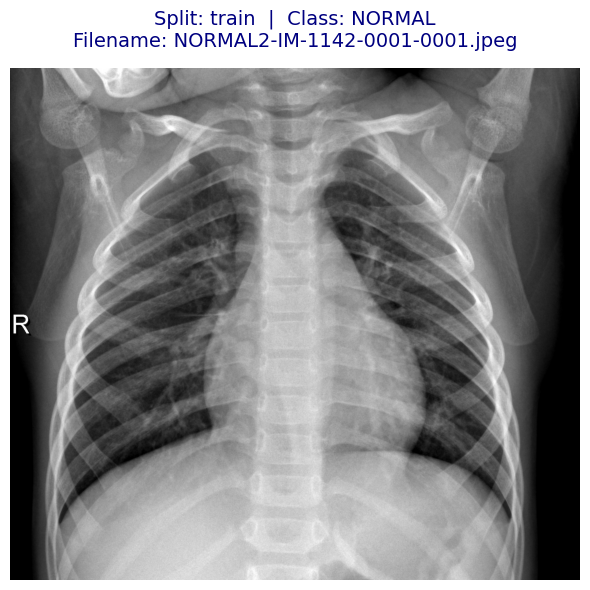

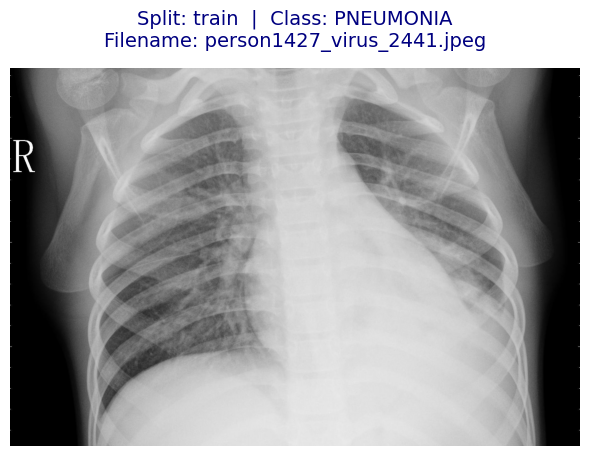

In [17]:
# ============================================
# Cell 11: Display Sample Images
# ============================================
def show_one(split, cls, figsize=(6,6), cmap='gray'):
    p = os.path.join(base, split, cls)
    files = [f for f in os.listdir(p) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    if len(files) == 0:
        print(f"No images found in {p}")
        return
    fn = random.choice(files)
    img = Image.open(os.path.join(p, fn)).convert('L')
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(f"Split: {split}  |  Class: {cls}\nFilename: {fn}", fontsize=14, color='navy', pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

show_one("train", "NORMAL")
show_one("train", "PNEUMONIA")

In [18]:
# ============================================
# Cell 12: Rebalance Validation Set (Optional)
# ============================================
new_val_count = 200
def rebuild_val():
    for cls in classes:
        src = os.path.join(base, "train", cls)
        dst = os.path.join(base, "val", cls)
        os.makedirs(dst, exist_ok=True)
        files = [f for f in os.listdir(src) if f.lower().endswith(('.png','.jpg','.jpeg'))]
        random.shuffle(files)
        move_files = files[:new_val_count]
        for f in move_files:
            shutil.move(os.path.join(src, f), os.path.join(dst, f))
        print(f"Moved {len(move_files)} {cls} images to val/")

rebuild_val()


Moved 200 NORMAL images to val/
Moved 200 PNEUMONIA images to val/


In [19]:
# ============================================
# Cell 13: Augment Minority Class (NORMAL)
# ============================================
train_normal_dir = os.path.join(base, "train", "NORMAL")
train_pneu_dir = os.path.join(base, "train", "PNEUMONIA")

normal_images = os.listdir(train_normal_dir)
pneu_images   = os.listdir(train_pneu_dir)

needed = len(pneu_images) - len(normal_images)
print("Augmenting", needed, "NORMAL images")

def augment_image(img):
    # Rotation
    img = img.rotate(random.randint(-12, 12))
    # Brightness
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.85,1.15))
    # Contrast
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.85,1.15))
    # Horizontal flip
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    return img

for i in tqdm(range(needed)):
    img_name = random.choice(normal_images)
    img_path = os.path.join(train_normal_dir, img_name)
    img = Image.open(img_path).convert("L")
    aug = augment_image(img)
    new_name = f"aug_normal_{i}.jpeg"
    aug.save(os.path.join(train_normal_dir, new_name))


Augmenting 2534 NORMAL images


100%|██████████| 2534/2534 [01:37<00:00, 25.95it/s]


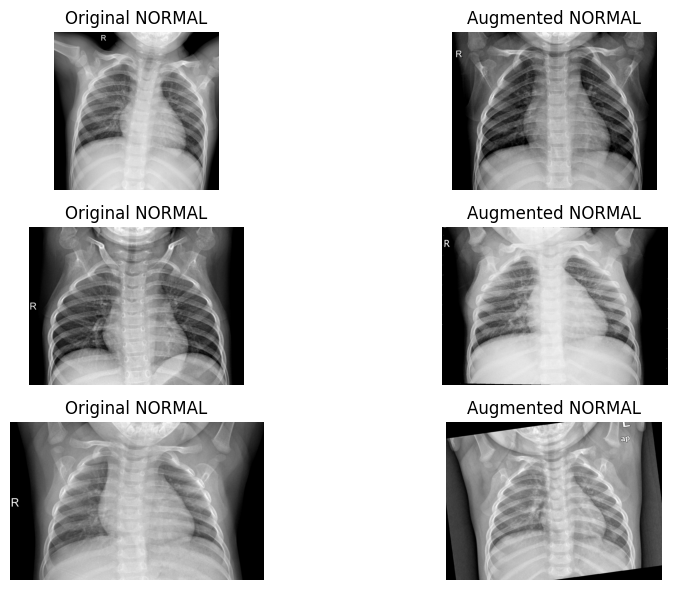

In [20]:
# ============================================
# Cell 14: Display Some Augmented Images
# ============================================
augmented = [f for f in os.listdir(train_normal_dir) if f.startswith("aug_")]
samples = 3
plt.figure(figsize=(10,6))
for i in range(samples):
    orig_img = Image.open(os.path.join(train_normal_dir, random.choice(normal_images)))
    aug_img  = Image.open(os.path.join(train_normal_dir, random.choice(augmented)))
    plt.subplot(samples, 2, 2*i+1)
    plt.imshow(orig_img, cmap="gray")
    plt.title("Original NORMAL"); plt.axis("off")
    plt.subplot(samples, 2, 2*i+2)
    plt.imshow(aug_img, cmap="gray")
    plt.title("Augmented NORMAL"); plt.axis("off")
plt.tight_layout(); plt.show()

In [5]:
# ============================================
# Cell 15: Load CLIP Model
# ============================================
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 261MiB/s]


In [22]:
# ============================================
# Cell 16: Extract Features and Save
# ============================================
save_dir = "/content/features_clip"
os.makedirs(save_dir, exist_ok=True)

def extract_split(split):
    features_list, labels_list = [], []
    print(f"\n===== Extracting: {split} =====")
    for cls_idx, cls_name in enumerate(classes):
        folder = os.path.join(base, split, cls_name)
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f"- {cls_name}: {len(files)} images")
        for f in tqdm(files):
            path = os.path.join(folder, f)
            img = Image.open(path).convert("RGB")
            img = preprocess(img).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = model.encode_image(img)
            features_list.append(feat.cpu().numpy()[0])
            labels_list.append(cls_idx)
    features = torch.tensor(features_list)
    labels   = torch.tensor(labels_list)
    torch.save((features, labels), f"{save_dir}/{split}_features.pt")
    print(f"Saved: {save_dir}/{split}_features.pt")

for s in splits:
    extract_split(s)



===== Extracting: train =====
- NORMAL: 3675 images


100%|██████████| 3675/3675 [02:42<00:00, 22.60it/s]


- PNEUMONIA: 3675 images


100%|██████████| 3675/3675 [01:32<00:00, 39.54it/s]
/tmp/ipython-input-3537066488.py:22: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  features = torch.tensor(features_list)


Saved: /content/features_clip/train_features.pt

===== Extracting: val =====
- NORMAL: 208 images


...

Saved: /content/features_clip/val_features.pt

===== Extracting: test =====
- NORMAL: 234 images


100%|██████████| 234/234 [00:09<00:00, 24.41it/s]


- PNEUMONIA: 390 images


100%|██████████| 390/390 [00:09<00:00, 42.02it/s]

Saved: /content/features_clip/test_features.pt


In [23]:
# ============================================
# Cell 17: Load Features
# ============================================
feature_dir = save_dir
train_features, train_labels = torch.load(f"{feature_dir}/train_features.pt")
val_features, val_labels     = torch.load(f"{feature_dir}/val_features.pt")
test_features, test_labels   = torch.load(f"{feature_dir}/test_features.pt")

print("Train:", train_features.shape, train_labels.shape)
print("Val:", val_features.shape, val_labels.shape)
print("Test:", test_features.shape, test_labels.shape)

Train: torch.Size([7350, 512]) torch.Size([7350])
Val: torch.Size([416, 512]) torch.Size([416])
Test: torch.Size([624, 512]) torch.Size([624])


In [24]:
# ============================================
# Cell 18: Normalize Features
# ============================================
train_features_norm = torch.nan_to_num((train_features - train_features.mean(0)) / train_features.std(0))
val_features_norm   = torch.nan_to_num((val_features   - val_features.mean(0))   / val_features.std(0))
test_features_norm  = torch.nan_to_num((test_features  - test_features.mean(0))  / test_features.std(0))


In [25]:
# ============================================
# Cell 19: Create Dataloaders
# ============================================
batch_size = 64
train_loader = DataLoader(TensorDataset(train_features_norm, train_labels), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(val_features_norm, val_labels), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(test_features_norm, test_labels), batch_size=batch_size, shuffle=False)

print("✔️ Dataloaders ready!")

✔️ Dataloaders ready!


In [27]:
# ============================================
# Cell 20: Define Classifier
# ============================================

class BalancedClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

model = BalancedClassifier().to(device)
summary(model, input_size=(512,))
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params}, Trainable params: {trainable_params}")


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]         131,328
              ReLU-2                  [-1, 256]               0
           Dropout-3                  [-1, 256]               0
            Linear-4                   [-1, 64]          16,448
              ReLU-5                   [-1, 64]               0
           Dropout-6                   [-1, 64]               0
            Linear-7                    [-1, 2]             130
Total params: 147,906
Trainable params: 147,906
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.56
Estimated Total Size (MB): 0.57
----------------------------------------------------------------
BalancedClassifier(
  (net): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
   

In [28]:
# ============================================
# Cell 21: Training Setup
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
epochs = 20

# Track history
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [29]:
# ============================================
# Cell 22: Training Loop
# ============================================
for epoch in range(epochs):
    # ----- Training -----
    model.train()
    train_loss = 0; correct = 0; total = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X.float())
        loss = criterion(outputs, y)
        loss.backward(); optimizer.step()
        train_loss += loss.item() * X.size(0)
        correct += (outputs.argmax(1) == y).sum().item()
        total += y.size(0)
    train_loss /= total
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ----- Validation -----
    model.eval()
    val_loss = 0; correct = 0; total = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X.float())
            loss = criterion(outputs, y)
            val_loss += loss.item() * X.size(0)
            correct += (outputs.argmax(1) == y).sum().item()
            total += y.size(0)
    val_loss /= total
    val_acc = 100 * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")


Epoch [1/20] | Train Loss: 0.3587 | Train Acc: 88.71% | Val Loss: 0.2175 | Val Acc: 92.07%
Epoch [2/20] | Train Loss: 0.1131 | Train Acc: 96.11% | Val Loss: 0.1816 | Val Acc: 92.79%
Epoch [3/20] | Train Loss: 0.0793 | Train Acc: 97.10% | Val Loss: 0.1754 | Val Acc: 93.99%
Epoch [4/20] | Train Loss: 0.0648 | Train Acc: 97.71% | Val Loss: 0.1841 | Val Acc: 93.03%
Epoch [5/20] | Train Loss: 0.0547 | Train Acc: 98.07% | Val Loss: 0.1850 | Val Acc: 94.23%
Epoch [6/20] | Train Loss: 0.0492 | Train Acc: 98.27% | Val Loss: 0.1832 | Val Acc: 94.47%
Epoch [7/20] | Train Loss: 0.0429 | Train Acc: 98.63% | Val Loss: 0.1767 | Val Acc: 95.43%
Epoch [8/20] | Train Loss: 0.0390 | Train Acc: 98.73% | Val Loss: 0.1812 | Val Acc: 95.19%
Epoch [9/20] | Train Loss: 0.0334 | Train Acc: 98.93% | Val Loss: 0.1862 | Val Acc: 94.95%
Epoch [10/20] | Train Loss: 0.0308 | Train Acc: 99.06% | Val Loss: 0.1873 | Val Acc: 95.43%
Epoch [11/20] | Train Loss: 0.0277 | Train Acc: 99.09% | Val Loss: 0.2053 | Val Acc: 94.9

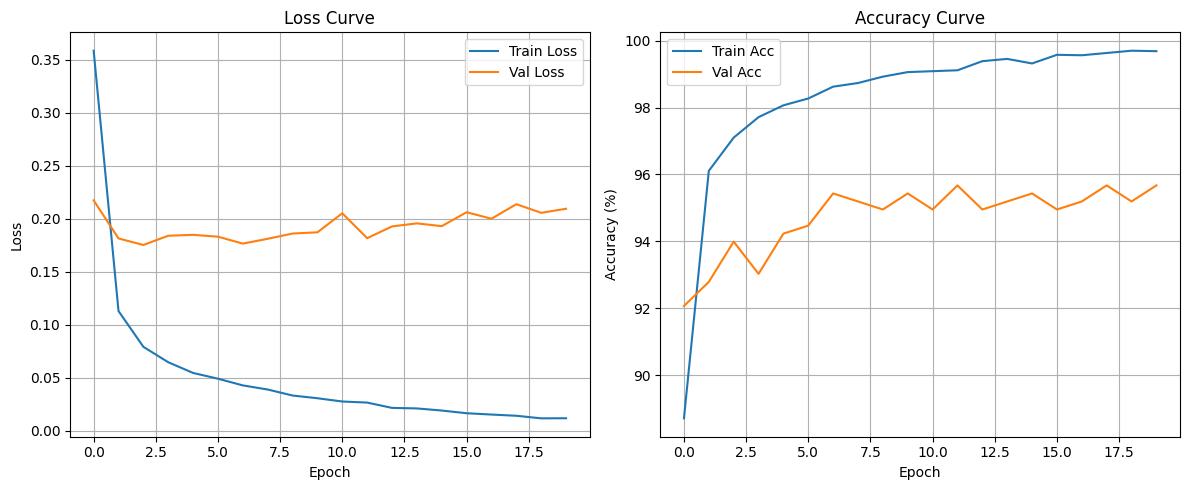

In [31]:
# ============================================
# Cell 23: Plot Training History
# ============================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.legend()
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curve"); plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

In [34]:
# ============================================
# Cell 24: Evaluate on Test Set
# ============================================
model.eval(); all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X.float())
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"\n🔥 Test Accuracy: {test_acc*100:.2f}%")


🔥 Test Accuracy: 85.26%


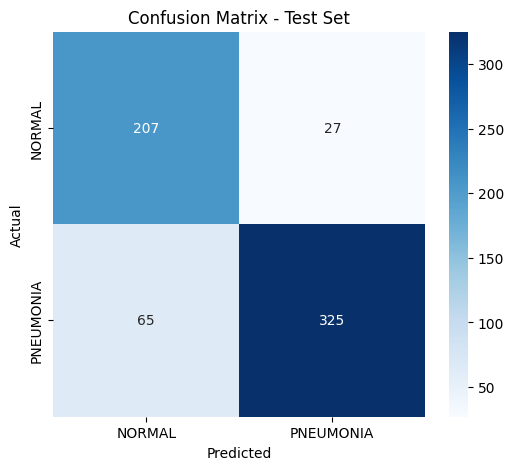

In [35]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix - Test Set"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()


In [36]:
# Classification Report
print(classification_report(all_labels, all_preds, target_names=classes))


              precision    recall  f1-score   support

      NORMAL       0.76      0.88      0.82       234
   PNEUMONIA       0.92      0.83      0.88       390

    accuracy                           0.85       624
   macro avg       0.84      0.86      0.85       624
weighted avg       0.86      0.85      0.85       624



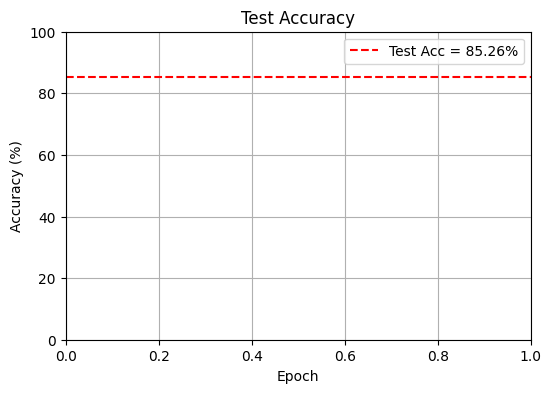

In [39]:
test_acc = 85.26  # كنسبة مئوية

plt.figure(figsize=(6,4))
plt.axhline(y=test_acc, color='red', linestyle='--', label=f"Test Acc = {test_acc:.2f}%")
plt.ylim(0, 100)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()


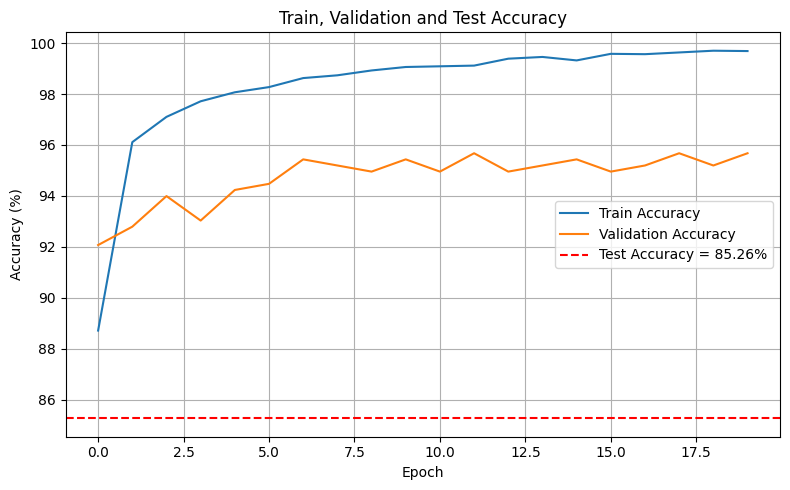

In [40]:
plt.figure(figsize=(8,5))

# Train & Validation
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

# Test (خط أفقي)
plt.axhline(y=test_acc, color='red', linestyle='--',
            label=f"Test Accuracy = {test_acc:.2f}%")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train, Validation and Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [43]:
# ============================================
# Cell 26: Save Model
# ============================================
save_path = "/content/drive/MyDrive/best_chest_model_2.pth"
torch.save(model.state_dict(), save_path)
print("✅ Model saved to:", save_path)

✅ Model saved to: /content/drive/MyDrive/best_chest_model_2.pth


# ============================================
# **Cell: Live Demo  - Single Image Test**
# ============================================


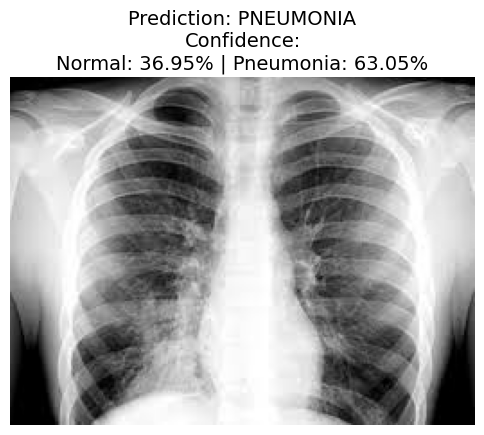

In [45]:
# --------------------------------------------
# 1. Load CLIP
# --------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# --------------------------------------------
# 2. Load trained classifier
# --------------------------------------------
classifier = BalancedClassifier().to(device)

save_path = "/content/drive/MyDrive/best_chest_model_2.pth"
classifier.load_state_dict(torch.load(save_path, map_location=device))
classifier.eval()

# --------------------------------------------
# 3. Select an image (change path if you want)
# --------------------------------------------
image_path = "/content/p.jpg"

image = Image.open(image_path).convert("RGB")

# --------------------------------------------
# 4. Extract CLIP features
# --------------------------------------------
with torch.no_grad():
    img_tensor = preprocess(image).unsqueeze(0).to(device)
    img_features = clip_model.encode_image(img_tensor)
    img_features = img_features / img_features.norm(dim=-1, keepdim=True)

# --------------------------------------------
# 5. Classification
# --------------------------------------------
with torch.no_grad():
    outputs = classifier(img_features.float())
    probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]

pred_class = np.argmax(probs)
classes = ["NORMAL", "PNEUMONIA"]

# --------------------------------------------
# 6. Display result
# --------------------------------------------
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction: {classes[pred_class]}\n"
    f"Confidence:\n"
    f"Normal: {probs[0]*100:.2f}% | Pneumonia: {probs[1]*100:.2f}%",
    fontsize=14
)

plt.show()


In [7]:
# ===============================
# Classifier Architecture
# ===============================
class BalancedClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

classifier = BalancedClassifier().to(device)
classifier.load_state_dict(
    torch.load("/content/drive/MyDrive/best_chest_model_2.pth",
               map_location=device)
)
classifier.eval()

print("✅ Classifier loaded")


✅ Classifier loaded


In [8]:
def classify_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = clip_model.encode_image(image_tensor)
        logits = classifier(features.float())
        probs = F.softmax(logits, dim=1)

    pred = probs.argmax(dim=1).item()
    confidence = probs.max().item()

    labels = {0: "Normal", 1: "Pneumonia"}
    return labels[pred], confidence


In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

print("✅ CLIP model loaded")

✅ CLIP model loaded


In [20]:
classifier = BalancedClassifier().to(device)
classifier.load_state_dict(
    torch.load("/content/drive/MyDrive/best_chest_model_2.pth", map_location=device)
)
classifier.eval()

print("✅ Trained classifier loaded")


✅ Trained classifier loaded


In [9]:
# ===============================
# Load LLM for Report Generation
# ===============================
from transformers import T5Tokenizer, T5ForConditionalGeneration

model_name = "google/flan-t5-large"
tokenizer = T5Tokenizer.from_pretrained(model_name)
llm = T5ForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if device=="cuda" else torch.float32
).to(device)

llm.eval()
print("✅ LLM loaded")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
`torch_dtype` is deprecated! Use `dtype` instead!


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ LLM loaded


In [25]:
def generate_medical_report(diagnosis, confidence):
    confidence = round(confidence * 100, 2)

    if diagnosis == "Pneumonia":
        findings = (
            "The chest X-ray image shows abnormal opacity patterns within the lung fields, "
            "suggestive of inflammatory processes commonly associated with pneumonia."
        )
        impression = (
            "The model predicts the presence of pneumonia based on learned radiographic "
            "features from the dataset."
        )
    else:
        findings = (
            "The lung fields appear clear with no significant abnormalities or opacities "
            "observed in the chest X-ray image."
        )
        impression = (
            "The model predicts a normal chest X-ray with no signs of pneumonia."
        )

    report = f"""
CHEST X-RAY MEDICAL REPORT
---------------------------------

Diagnosis:
{diagnosis}

Model Confidence:
{confidence}%

Findings:
{findings}

Impression:
{impression}

Note:
This report was generated by an AI-assisted system using CLIP-based feature
extraction and a neural network classifier. It is intended for academic and
research purposes only.
"""
    return report


Saving p.jpg to p (5).jpg
Diagnosis: Pneumonia
Confidence: 96.38 %

Medical Report:
 
CHEST X-RAY MEDICAL REPORT
---------------------------------

Diagnosis:
Pneumonia

Model Confidence:
96.38%

Findings:
The chest X-ray image shows abnormal opacity patterns within the lung fields, suggestive of inflammatory processes commonly associated with pneumonia.

Impression:
The model predicts the presence of pneumonia based on learned radiographic features from the dataset.

Note:
This report was generated by an AI-assisted system using CLIP-based feature
extraction and a neural network classifier. It is intended for academic and
research purposes only.



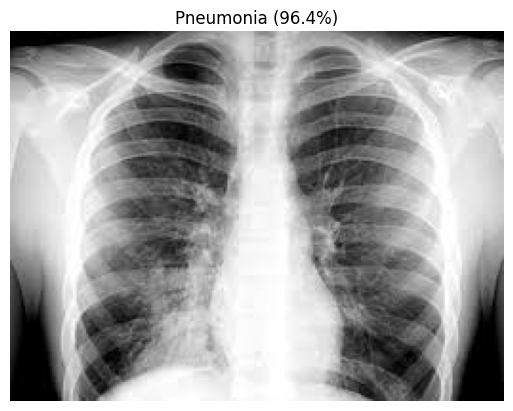

In [26]:
from google.colab import files
import torch.nn.functional as F

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

diagnosis, confidence = classify_image(image_path)
report = generate_medical_report(diagnosis, confidence)

print("Diagnosis:", diagnosis)
print("Confidence:", round(confidence*100, 2), "%")
print("\nMedical Report:\n", report)

img = Image.open(image_path)
plt.imshow(img, cmap="gray")
plt.title(f"{diagnosis} ({confidence*100:.1f}%)")
plt.axis("off")
plt.show()